# Preprocesmiento funciones

In [44]:
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image  

def Leer_Imagen(ruta, nombre, tamaño=None):
    """
    Carga una imagen desde un archivo y la convierte en un arreglo normalizado.

    Parámetros:
        ruta (str): Ruta del directorio donde se encuentra la imagen.
        nombre (str): Nombre del archivo de imagen (incluye la extensión).
        tamaño (tuple[int, int], opcional): Tamaño deseado (ancho, alto). 
                                            Si es None, mantiene el tamaño original.

    Retorna:
        np.ndarray: Imagen como arreglo NumPy normalizado en rango [0, 1].
    """
    img = Image.open(ruta + nombre)
    if tamaño is not None:
        img = img.resize(tamaño)
    imagen = np.asarray(img, dtype=np.float32) / 255.0
    return imagen

def Extraer_RGB(imagen):
    """
    Extrae los canales RGB de una imagen y los reorganiza en una matriz de píxeles.

    Parámetros:
        imagen (np.ndarray): Imagen en formato NumPy con 3 canales.

    Retorna:
        np.ndarray: Matriz de tamaño (N, 3), donde cada fila representa un píxel (R, G, B).
    """
    I1 = np.asarray(imagen, dtype=np.float32)
    R, G, B = I1[:, :, 0], I1[:, :, 1], I1[:, :, 2]
    XR = R.reshape((-1, 1))
    XG = G.reshape((-1, 1))
    XB = B.reshape((-1, 1))
    rgb = np.concatenate((XR, XG, XB), axis=1)
    return rgb

def Visualizar_Imagen(imagen):
    """
    Muestra una imagen sin ejes usando matplotlib.

    Parámetros:
        imagen (np.ndarray): Imagen en formato NumPy a mostrar.
    """
    plt.figure()
    plt.imshow(imagen)
    plt.axis('off')
    plt.title("Imagen original")
    plt.show()
    plt.close()

def Listar_Archivos(ruta, extensiones=None):
    """
    Devuelve una lista con los nombres de todos los archivos dentro de una carpeta.
    Si se especifican extensiones (por ejemplo ['.jpg', '.png']), solo devuelve esos tipos.

    Parámetros:
        carpeta (str): Ruta de la carpeta a explorar.
        extensiones (list[str], opcional): Extensiones de archivo a filtrar.

    Retorna:
        list[str]: Lista con los nombres de los archivos encontrados.
    """
    archivos = []
    for nombre in os.listdir(ruta):
        ruta_completa = os.path.join(ruta, nombre)
        if os.path.isfile(ruta_completa):
            if extensiones is None or os.path.splitext(nombre)[1].lower() in extensiones:
                archivos.append(nombre)
    return archivos


ruta = r'C:\Users\narro\OneDrive - Fundacion Universidad de las Americas Puebla\semestre 9\redes\redes_local\datos\data\\'

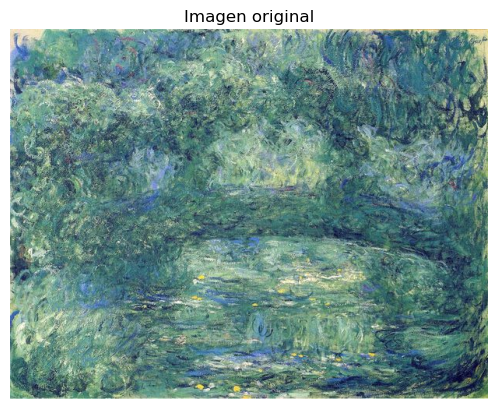

In [45]:
imagen = Leer_Imagen(ruta, "Claude_Monet_1.jpg")
Visualizar_Imagen(imagen)
rgb = Extraer_RGB(imagen)

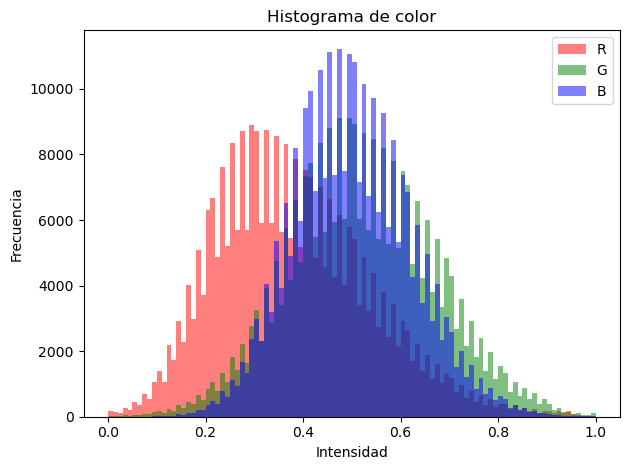

In [46]:
import matplotlib.pyplot as plt

def plot_histograma_color(rgb, bins=100):
    """
    Dibuja histogramas de los canales R, G y B.
    """
    plt.figure()
    plt.hist(rgb[:, 0], bins=bins, alpha=0.5, label='R', color='Red')
    plt.hist(rgb[:, 1], bins=bins, alpha=0.5, label='G', color = 'Green')
    plt.hist(rgb[:, 2], bins=bins, alpha=0.5, label='B', color = 'Blue')
    plt.xlabel("Intensidad")
    plt.ylabel("Frecuencia")
    plt.title("Histograma de color")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_histograma_color(rgb)

In [47]:
import numpy as np
from matplotlib.colors import rgb_to_hsv

def contraste_rms_desde_rgb(rgb: np.ndarray) -> float:
    """
    Calcula el contraste RMS (desviación estándar de intensidades en gris)
    a partir de un arreglo RGB de forma (N, 3) con valores en [0, 255].
    """
    rgb = rgb.astype(np.float32)

    # Convertir a escala de grises usando luminancia estándar
    # Y = 0.299 R + 0.587 G + 0.114 B
    R = rgb[:, 0]
    G = rgb[:, 1]
    B = rgb[:, 2]
    Y = 0.299 * R + 0.587 * G + 0.114 * B  # intensidades en [0, 255]

    # Normalizar a [0,1]
    Y_norm = Y / 255.0

    # Contraste RMS = desviación estándar de intensidades normalizadas
    contraste_rms = Y_norm.std()

    return float(contraste_rms)


import numpy as np
import cv2

def imagen_a_grises(imagen: np.ndarray) -> np.ndarray:
    """
    Convierte una imagen RGB a escala de grises normalizada en [0, 1].
    Si ya viene en grises, solo normaliza.
    """
    I = imagen.astype(np.float32)

    # Si es RGB (H, W, 3)
    if I.ndim == 3 and I.shape[2] == 3:
        # Luminancia estándar
        gray = 0.299 * I[:, :, 0] + 0.587 * I[:, :, 1] + 0.114 * I[:, :, 2]
    else:
        # Ya es una sola banda
        gray = I

    # Normalizar a [0, 1]
    gray_norm = gray / 255.0
    return gray_norm

import numpy as np


def entropia_shannon(gray_norm):
    hist, _ = np.histogram(gray_norm.ravel(), bins=256, range=(0,1), density=True)
    hist = hist + 1e-12  # evitar log(0)
    H = -np.sum(hist * np.log(hist))
    return float(H)


def extraer_composicion_luz(gray, grid_size=3, bright_percentile=90):
    """
    Extrae atributos de composición de luz de una pintura.
    
    Parámetros:
    - imagen: np.ndarray RGB en formato uint8 o float
    - grid_size: 3 para 3x3, 4 para 4x4
    - bright_percentile: percentil para definir lo que se considera "pixel brillante"

    Regresa:
    - dict con:
        - mean_block_r_c
        - pct_bright_block_r_c
        - center_mean_ratio
        - center_bright_ratio
        - lum_centroid_x
        - lum_centroid_y
    """

    # -------------------------------
    # Convertir a grises normalizado
    # -------------------------------

    gray_norm = gray / 255.0  # [0,1]
    H, W = gray_norm.shape

    # Umbral de brillo alto
    bright_thr = np.percentile(gray_norm, bright_percentile)

    # -------------------------------
    # Dividir en rejilla grid_size x grid_size
    # -------------------------------
    feats = {}
    h_step = H // grid_size
    w_step = W // grid_size

    block_means = []
    block_brights = []

    for r in range(grid_size):
        for c in range(grid_size):
            block = gray_norm[r*h_step:(r+1)*h_step, c*w_step:(c+1)*w_step]

            mean_int = block.mean()
            pct_bright = (block > bright_thr).mean()

            feats[f"mean_block_{r}_{c}"] = float(mean_int)
            feats[f"pct_bright_block_{r}_{c}"] = float(pct_bright)

            block_means.append(mean_int)
            block_brights.append(pct_bright)

    block_means = np.array(block_means)
    block_brights = np.array(block_brights)

    # -------------------------------
    # Razón centro/global
    # -------------------------------
    # índice del bloque central
    center_idx = (grid_size * grid_size) // 2

    center_mean = block_means[center_idx]
    center_bright = block_brights[center_idx]

    global_mean = block_means.mean() + 1e-8
    global_bright = block_brights.mean() + 1e-8

    H = entropia_shannon(gray_norm)

    feats["H_shannon"] = float(H)
    feats["center_mean_ratio"] = float(center_mean / global_mean)
    feats["center_bright_ratio"] = float(center_bright / global_bright)

    # -------------------------------
    # Centroide de luminosidad
    # -------------------------------
    y_indices, x_indices = np.indices(gray_norm.shape)
    total_light = gray_norm.sum() + 1e-8

    lum_x = (x_indices * gray_norm).sum() / total_light
    lum_y = (y_indices * gray_norm).sum() / total_light

    # Normalizar a [0,1]
    feats["lum_centroid_x"] = float(lum_x / W)
    feats["lum_centroid_y"] = float(lum_y / H)

    return feats

import numpy as np

def extraer_aspect_ratio(imagen: np.ndarray) -> dict:
    """
    Calcula la relación de aspecto y el área en píxeles.
    """
    H, W = imagen.shape[:2]
    aspect_ratio = W / H
    area = H * W

    return {
        "aspect_ratio": float(aspect_ratio),
        "image_area": float(area),
    }

def extraer_brightness_ratio(imagen: np.ndarray, bright_percentile: int = 90) -> dict:
    """
    Calcula el porcentaje global de píxeles considerados "brillantes"
    según un percentil de intensidad en gris.
    """
    gray_norm = imagen_a_grises(imagen)  # [0,1]
    thr = np.percentile(gray_norm, bright_percentile)
    bright_ratio = (gray_norm > thr).mean()

    return {
        "bright_ratio_global": float(bright_ratio),
    }

def extraer_simetria(imagen: np.ndarray) -> dict:
    """
    Calcula una medida simple de simetría horizontal y vertical
    usando la imagen en gris normalizada.
    Valores cercanos a 1 = más simétrica, cercanos a 0 = menos.
    """
    gray_norm = imagen_a_grises(imagen)  # [0,1]

    # Flip horizontal y vertical
    gray_hflip = np.fliplr(gray_norm)
    gray_vflip = np.flipud(gray_norm)

    # Diferencias normalizadas
    diff_h = np.abs(gray_norm - gray_hflip)
    diff_v = np.abs(gray_norm - gray_vflip)

    # Normalizar por max posible (que sería 1 en [0,1])
    # Usamos 1 - media de la diferencia como "similitud"
    sim_h = 1.0 - diff_h.mean()
    sim_v = 1.0 - diff_v.mean()

    return {
        "symmetry_horizontal": float(sim_h),
        "symmetry_vertical": float(sim_v),
    }


def extraer_colorfulness(imagen: np.ndarray) -> dict:
    """
    Calcula la métrica de 'colorfulness' de Hasler–Suesstrunk.
    Espera imagen RGB en [0,255] o [0,1] (se adapta).
    """
    img = imagen.astype(np.float32)

    # Si está en [0,1], la llevamos a [0,255] solo para consistencia de escala
    if img.max() <= 1.0:
        img = img * 255.0

    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    # Componentes rg y yb
    rg = R - G
    yb = 0.5 * (R + G) - B

    # Medias y desviaciones
    std_rg = rg.std()
    std_yb = yb.std()
    mean_rg = rg.mean()
    mean_yb = yb.mean()

    # Fórmula de colorfulness
    colorfulness = np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2)

    return {
        "colorfulness": float(colorfulness),
    }


In [ ]:

def extraer_caracteristicas(imagen):
    """
    rgb: np.ndarray de forma (N, 3) con valores en [0, 255]
    
    Regresa:
        feats: dict con estadísticas de R, G, B, saturación y brillo.
    """
    # Asegurar float
    rgb = Extraer_RGB(imagen)
    rgb = rgb.astype(np.float32)

    # Estadísticas básicas por canal (en 0–255)
    mean_rgb = rgb.mean(axis=0)          # [mean_R, mean_G, mean_B]
    std_rgb  = rgb.std(axis=0)           # [std_R, std_G, std_B]
    min_rgb  = rgb.min(axis=0)
    max_rgb  = rgb.max(axis=0)

    # Convertir a [0,1] para pasar a HSV
    rgb_norm = rgb / 255.0               # (N, 3) en [0,1]

    # matplotlib.colors.rgb_to_hsv espera (M,N,3), así que reacomodamos
    hsv = rgb_to_hsv(rgb_norm.reshape(-1, 1, 3)).reshape(-1, 3)
    H = hsv[:, 0]  #entropia
    S = hsv[:, 1]   # Saturación
    V = hsv[:, 2]   # Brillo / Valor

    # Estadísticas de saturación y brillo
    mean_S = S.mean()
    std_S  = S.std()
    mean_V = V.mean()
    std_V  = V.std()

    #rms
    rms = contraste_rms_desde_rgb(rgb)

    #textura

    gray = imagen_a_grises(imagen)

    # Sobel horizontal (detecta cambios verticales)
    sobel_x = cv2.Sobel(gray, cv2.CV_32F, dx=1, dy=0, ksize=3)
    # Sobel vertical (detecta cambios horizontales)
    sobel_y = cv2.Sobel(gray, cv2.CV_32F, dx=0, dy=1, ksize=3)

    # Magnitud del gradiente (fuerza total del borde)
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

    sobel_mean = float(sobel_mag.mean())
    sobel_std = float(sobel_mag.std())

    # Umbral para "borde fuerte": percentil 75 de la magnitud
    threshold = np.percentile(sobel_mag, 75)
    sobel_pct_strong = float((sobel_mag > threshold).mean())

    lap = cv2.Laplacian(gray, cv2.CV_32F, ksize=3)

    # Usamos el valor absoluto para medir "cantidad" de detalle, sin signo
    lap_abs = np.abs(lap)

    laplacian_mean_abs = float(lap_abs.mean())
    laplacian_std_abs = float(lap_abs.std())

    #Gabor
    # Tamaño del kernel y parámetros base (puedes ajustarlos)
    ksize = 21       # tamaño del filtro (impar)
    sigma = 4.0      # ancho de la gaussiana
    lambd = 10.0     # longitud de onda
    gamma = 0.5      # relación de aspecto
    psi = 0          # fase

    # Orientaciones en radianes para gabor
    thetas = {
        "0": 0,
        "45": np.pi / 4,
        "90": np.pi / 2,
        "135": 3 * np.pi / 4,
    }

    featsg = {}

    for name, theta in thetas.items():
        # Crear kernel de Gabor para esta orientación
        kernel = cv2.getGaborKernel(
            ksize=(ksize, ksize),
            sigma=sigma,
            theta=theta,
            lambd=lambd,
            gamma=gamma,
            psi=psi,
            ktype=cv2.CV_32F,
        )

        # Convolucionar con la imagen
        gabor_resp = cv2.filter2D(gray, cv2.CV_32F, kernel)

        # Magnitud absoluta
        gabor_abs = np.abs(gabor_resp)

        # Métricas: media y desviación estándar
        featsg[f"gabor_mean_abs_{name}"] = float(gabor_abs.mean())
        featsg[f"gabor_std_abs_{name}"] = float(gabor_abs.std())

    
    feats_luz = extraer_composicion_luz(gray, grid_size=3)

    
    feats = {
        "mean_R": mean_rgb[0],
        "mean_G": mean_rgb[1],
        "mean_B": mean_rgb[2],
        "std_R": std_rgb[0],
        "std_G": std_rgb[1],
        "std_B": std_rgb[2],
        "min_R": min_rgb[0],
        "min_G": min_rgb[1],
        "min_B": min_rgb[2],
        "max_R": max_rgb[0],
        "max_G": max_rgb[1],
        "max_B": max_rgb[2],
        "mean_S": mean_S,
        "std_S": std_S,
        "mean_V": mean_V,
        "std_V": std_V,
        "rms": rms,
        "sobel_mean": sobel_mean,
        "sobel_std": sobel_std,
        "sobel_pct_strong": sobel_pct_strong,
        "laplacian_mean_abs": laplacian_mean_abs,
        "laplacian_std_abs": laplacian_std_abs,

    }

    feats.update(featsg)
    feats.update(feats_luz)


    return feats


In [54]:
feats = extraer_caracteristicas(imagen)

In [55]:
len(feats)

53

In [52]:
feats

{'mean_R': np.float32(0.38094503),
 'mean_G': np.float32(0.5201876),
 'mean_B': np.float32(0.50096834),
 'std_R': np.float32(0.15786402),
 'std_G': np.float32(0.14880532),
 'std_B': np.float32(0.120585635),
 'min_R': np.float32(0.0),
 'min_G': np.float32(0.0),
 'min_B': np.float32(0.0),
 'max_R': np.float32(1.0),
 'max_G': np.float32(1.0),
 'max_B': np.float32(1.0),
 'mean_S': np.float32(0.32512194),
 'std_S': np.float32(0.13153191),
 'mean_V': np.float32(0.0021147325),
 'std_V': np.float32(0.0005422809),
 'rms': 0.0005712261190637946,
 'sobel_mean': 0.0016626921715214849,
 'sobel_std': 0.0011315095471218228,
 'sobel_pct_strong': 0.2500017143836791,
 'laplacian_mean_abs': 0.001799278543330729,
 'laplacian_std_abs': 0.001593589666299522,
 'gabor_mean_abs_0': 0.012240201234817505,
 'gabor_std_abs_0': 0.006657083984464407,
 'gabor_mean_abs_45': 0.023661205545067787,
 'gabor_std_abs_45': 0.008332958444952965,
 'gabor_mean_abs_90': 0.012612634338438511,
 'gabor_std_abs_90': 0.00767929758876

# Blanceo de Clases (comunismo)

SMOTE pipeline para poder tenre clases dle mismo tmaño que la mas grande 

class weights 